# Create Images of Enemy Sprite Explosions

In [15]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

In [6]:
from colors_map import *
raw_level_color_schemes = """
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_YELLOW,M_ORANGE  ; Level 1
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_LTBLUE,M_BLUE    ; Level 4
        .BYTE M_GREEN,M_LTGREEN,M_ORANGE,M_LTBLUE,M_BLUE  ; Level 5
        .BYTE M_ORANGE,M_YELLOW,M_ORANGE,M_GRAY2,M_BLACK  ; Level 6
        .BYTE M_GRAY1,M_CYAN,M_LTGREEN,M_LTRED,M_RED      ; Level 7
        .BYTE M_BLACK,M_GRAY2,M_LTRED,M_LTBLUE,M_BLUE     ; Level 8
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_GRAY1,M_GRAY2,M_GRAY2,M_LTRED,M_RED       ; Level 10
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_BLUE,M_CYAN,M_ORANGE,M_GRAY2,M_GRAY1      ; Level 12
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_RED,M_LTRED,M_ORANGE,M_YELLOW,M_ORANGE    ; Level 15
"""
raw_level_color_schemes = [l[14:57].split(',') for l in raw_level_color_schemes.split('\n')][1:-1]
raw_level_color_schemes = [[x.strip() for x in l] for l in raw_level_color_schemes]
level_colors = [None]
for l in raw_level_color_schemes:
    colors = (color_constants[l[3]], "c64_white",color_constants[l[4]])
    level_colors += [colors]
level_colors[1]

('c64_yellow', 'c64_white', 'c64_orange')

## Bullet Arrays

In [46]:
from PIL import Image, ImageFilter, ImageColor, ImageDraw, ImageFont
def addBlackOutline(img):
    stroke_radius = 5
    stroke_image = Image.new("RGBA", img.size, (0, 0, 0, 255))
    img_alpha = img.getchannel(3).point(lambda x: 255 if x>0 else 0)
    stroke_alpha = img_alpha.filter(ImageFilter.MaxFilter(stroke_radius))
    # optionally, smooth the result
    stroke_alpha = stroke_alpha.filter(ImageFilter.SMOOTH)
    stroke_image.putalpha(stroke_alpha)
    output = Image.alpha_composite(stroke_image, img)
    return output

def add_alpha(img, alpha):
    img2 = img.copy()
    img2.putalpha(alpha)
    img.paste(img2, img)
    return img

resize = lambda img, scale: img.resize((int(img.width * scale), int(img.height * scale)), Image.NEAREST)

In [2]:
level_bullets = [
"0D","12","0D","0C","12","0D","0E","0D",
"10","0F","0C","0C","0E","0D","0D","0C"
]

In [5]:
!mkdir -p enemy_bullets

In [36]:
level_bullets[8:]

['10', '0F', '0C', '0C', '0E', '0D', '0D', '0C']

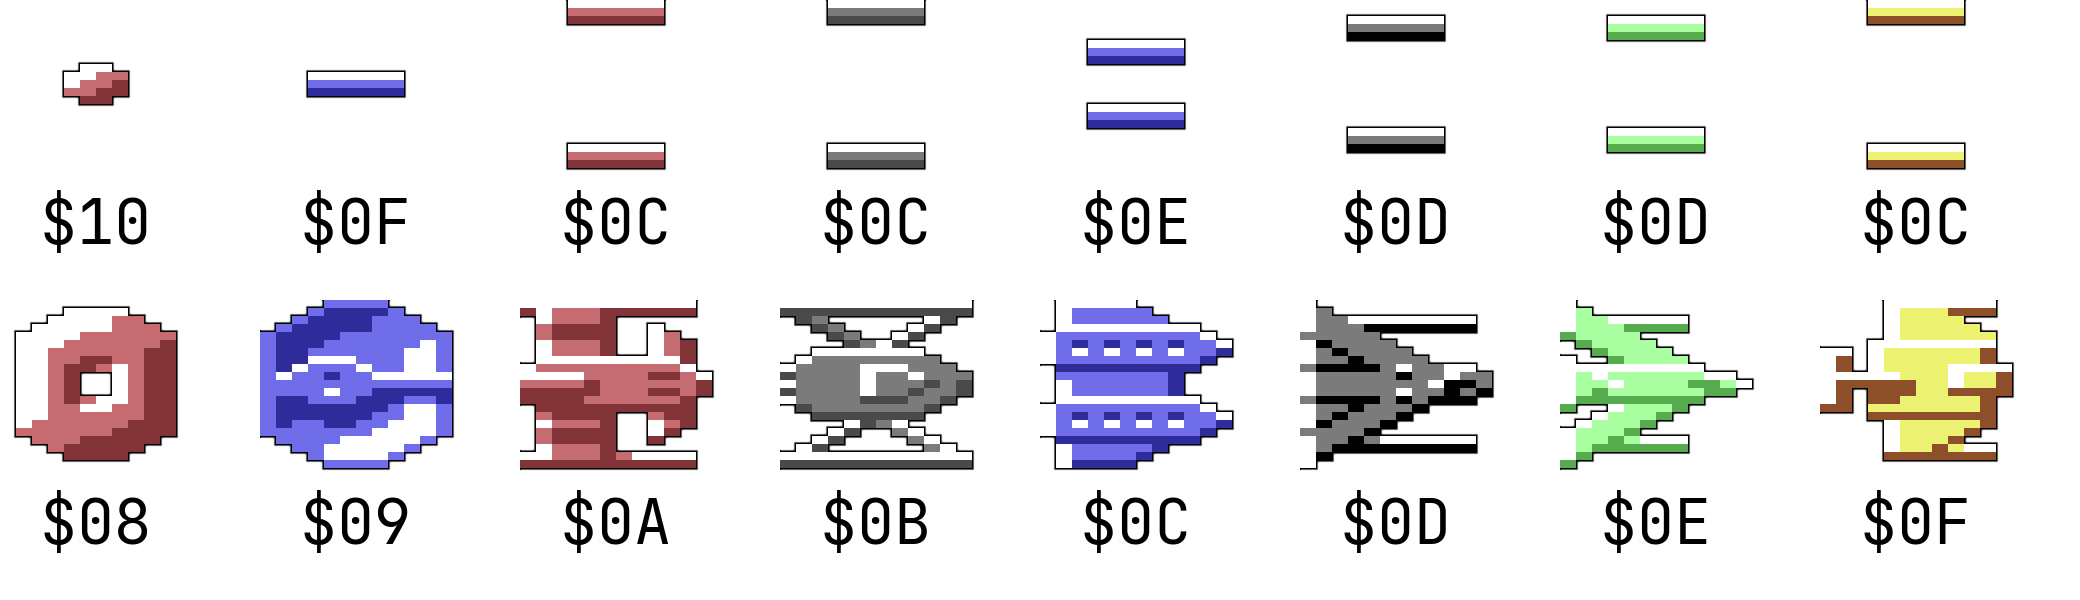

In [41]:
import random

offset = 260
for i,bullets in enumerate([level_bullets[:8],level_bullets[8:]]):
    img = Image.new('RGBA', (len(bullets) * (offset), 600))
    draw = ImageDraw.Draw(img)
    x,y = 0,0
    for index, sprite_name in enumerate(bullets):
        enemy_sprite = f"{index + 8 if i else index:02X}"
        level = random.randint(1,15)

        bullet = Image.open(f"uridimine_sprites/{level}_{sprite_name}_outlined.png")
        img.paste(bullet, (x,y),mask=bullet)
        label_text = "$"+sprite_name
        label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
        label_x = x + 40
        label_y = y + 180
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")

        y += 300
        bullet = Image.open(f"meanie_sprites/{level}_MEANIE_{enemy_sprite}.png")
        bullet = addBlackOutline(resize(bullet,8))
        img.paste(bullet, (x,y),mask=bullet)
        label_text = "$"+enemy_sprite
        label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
        label_x = x + 40
        label_y = y + 180
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
        y -= 300
        x += offset

    img.save(f"enemy_bullets/bullet_array_{i}.png")
img

## Create Image of Bullet Firing

In [45]:
from PIL import Image
def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surfaces_raw/{level}.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def make_shadow(img, color=(0x4a, 0x4a, 0x4a, 255)):
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

def make_mask(i):
    img = i.copy()
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] != 0:
            new_image.append((0xff, 0xff, 0xff))
        else:
            new_image.append((0,0,0))
    # update image data
    img.putdata(new_image)
    return img
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]

In [43]:
from PIL import Image

img = Image.open(f"meanie_sprites/1_MEANIE_01.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
meanie = img.copy()


## Create Image for Maybe Fire Bullet

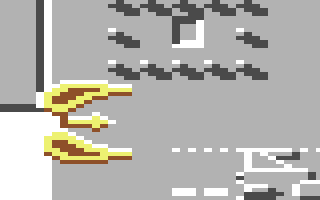

In [136]:
level = 1
diagram = get_surface_snippet(level=level, x_offset=485, y_offset = 60, width=80, height = 50)

img = Image.open(f"meanie_sprites/{level}_MEANIE_01.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

meanie = img.copy()
meanie_pos = (18,40)
diagram.paste(meanie, meanie_pos, mask=meanie)

img = resize(diagram,2)
img.save("enemy_bullets/level9_maybe_fire_bullet.png")
img

## Create Image for Fire Bullet

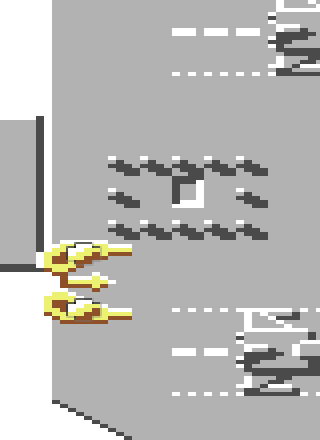

In [87]:
level = 1
diagram = get_surface_snippet(level=level, x_offset=485, y_offset = 20, width=80, height = 110)

img = Image.open(f"meanie_sprites/{level}_MEANIE_01.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

meanie = img.copy()
meanie_pos = (18,120)
diagram.paste(meanie, meanie_pos, mask=meanie)

bullet = Image.open(f"uridimine_sprites/{level}_12_outlined.png")
bullet = resize(bullet, 0.25)
bullet_pos = (18,120)
diagram.paste(bullet, bullet_pos, mask=bullet)

img = resize(diagram,2)
img.save("enemy_bullets/level9_fire_bullet.png")
img

## Create Image for Animate Bullet

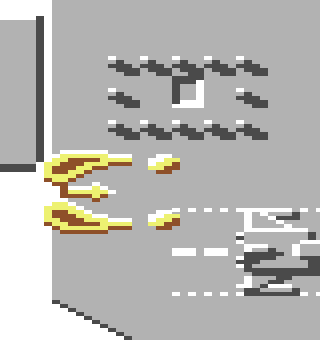

In [84]:
level = 1
diagram = get_surface_snippet(level=level, x_offset=485, y_offset = 45, width=80, height = 85)

img = Image.open(f"meanie_sprites/{level}_MEANIE_01.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

meanie = img.copy()
meanie_pos = (18,75)
diagram.paste(meanie, meanie_pos, mask=meanie)

bullet = Image.open(f"uridimine_sprites/{level}_12.png")
bullet_pos = (58,75)
diagram.paste(bullet, bullet_pos, mask=bullet)

img = resize(diagram,2)
img.save("enemy_bullets/level9_animate_bullet.png")
img

## Create Image for Bullet Expired

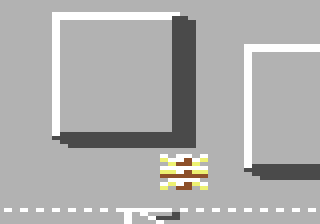

In [121]:
level = 1
diagram = get_surface_snippet(level=level, x_offset=595, y_offset = 45, width=80, height = 56)

img = Image.open(f"meanie_sprites/{level}_MEANIE_01.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
"""
meanie = img.copy()
meanie_pos = (18,75)
diagram.paste(meanie, meanie_pos, mask=meanie)
"""
bullet = Image.open(f"uridimine_sprites/{level}_14.png")
bullet_pos = (68,65)
diagram.paste(bullet, bullet_pos, mask=bullet)

img = resize(diagram,2)
img.save("enemy_bullets/level9_bullet_expired.png")
img

## Create Image of Bullet Exploding

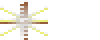

In [110]:
level=1
offset = 0
frames = [f"{x:02X}" for x in range(0x14,0x1e,1)]
frames_with_alpha = list(zip(frames,range(0, 255, 30)))

img = Image.new('RGBA', (100, 40))
x,y = 0,0
for sprite_name,alpha in frames_with_alpha:
    bullet = Image.open(f"uridimine_sprites/{level}_{sprite_name}.png")

    bullet2 = bullet.copy()
    bullet2.putalpha(alpha)
    bullet.paste(bullet2, bullet)

    img.paste(bullet, (x,y),mask=bullet)
    x+= offset

#img.save("uridimine/level9_launch_alpha.png")
explosion_alpha = img
explosion_alpha

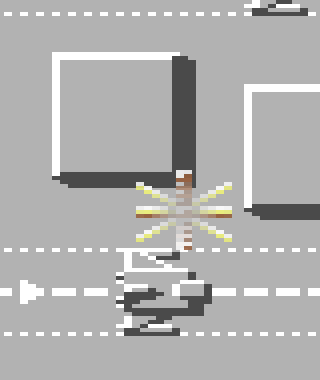

In [123]:
level = 1
diagram = get_surface_snippet(level=level, x_offset=595, y_offset = 35, width=80, height = 95)

img = Image.open(f"meanie_sprites/{level}_MEANIE_01.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

bullet = explosion_alpha
bullet_pos = (68,85)
diagram.paste(bullet, bullet_pos, mask=bullet)

img = resize(diagram,2)
img.save("enemy_bullets/level9_bullet_explodes.png")
img

## Bullet Explosion Sequence

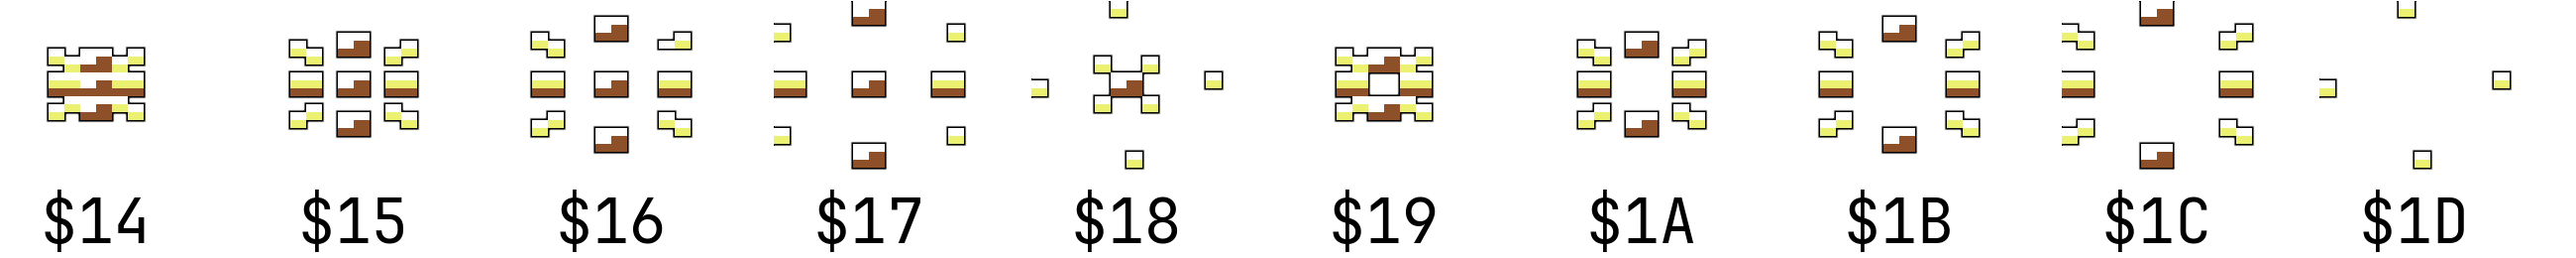

In [139]:
from PIL import Image, ImageDraw, ImageFont
level=1
offset = 260
frames = [f"{x:02X}" for x in range(0x14,0x1e,1)]
img = Image.new('RGBA', (len(frames) * (offset), 260))
draw = ImageDraw.Draw(img)
x,y = 1,1
for sprite_name in frames:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}_outlined.png")
    img.paste(manta, (x,y),mask=manta)

    label_text = "$"+sprite_name
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
    label_x = x + 40
    label_y = y + 180
    draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
    
    x+= offset

img.save("enemy_bullets/level9_explosion_sequence.png")
img

# Scratchpad